In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,  Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq

In [2]:
llm = ChatGroq(
    model = "openai/gpt-oss-120b"
)

In [3]:
from langgraph.graph.message import add_messages

class chatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [4]:
def chat_node(state: chatState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {'messages': [response]}

In [5]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(chatState)

graph.add_node("chat Node", chat_node)

graph.add_edge(START, "chat Node")
graph.add_edge("chat Node", END)

chatbot = graph.compile()

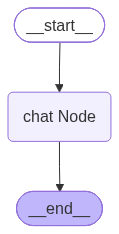

In [6]:
chatbot

In [7]:
from langchain_core.messages import HumanMessage

initial_state = {
    'messages': [HumanMessage(content='what is AI')]
}

response = chatbot.invoke(initial_state)

response

{'messages': [HumanMessage(content='what is AI', additional_kwargs={}, response_metadata={}, id='b559dc56-05d5-4d16-8fce-6c6e5c0d2642'),
  AIMessage(content='**Artificial Intelligence (AI)** is a branch of computer science that focuses on creating machines and software capable of performing tasks that normally require human intelligence. These tasks include learning, reasoning, problem‑solving, perception, language understanding, and decision‑making.\n\n### Core Concepts\n\n| Concept | What It Means |\n|---------|---------------|\n| **Machine Learning (ML)** | Algorithms that improve their performance automatically through experience (e.g., recognizing images after being shown many examples). |\n| **Deep Learning** | A subset of ML that uses multi‑layered neural networks to model complex patterns (e.g., speech‑to‑text, image generation). |\n| **Natural Language Processing (NLP)** | Techniques for understanding, generating, and translating human language (e.g., chatbots, translators). |

In [8]:
while True:
    user_message = input('Type here: ')
    print('User:', user_message)
    if user_message.strip().lower() in ['exit','quit','bye']:
        print('AI: Thanks for the visting!')
        break
    response = chatbot.invoke({'messages': [HumanMessage(content= user_message)]})
    print('AI:', response['messages'][-1].content)


User: 
AI: Hello! How can I help you today?
User: 
AI: Hello! How can I assist you today?
User: 
AI: Hello! How can I assist you today?
User: 
AI: It looks like your message came through empty. Could you let me know what you’d like help with? I'm here to assist!
User: 
AI: It looks like your message came through empty. How can I assist you today?
User: how to break infinite loop 
AI: Sure! An “infinite loop” is a loop that never terminates on its own because its exit condition is never met (or there is no exit condition at all). While sometimes you *want* an infinite loop (e.g., a server that runs forever), most of the time you need a way to stop it—either automatically when a condition is satisfied or manually by the user.

Below are several common strategies for breaking out of infinite loops in different programming languages, plus some general best‑practice tips.

---

## 1. Use a Proper Exit Condition

The most reliable way to avoid an infinite loop is to make sure the loop’s cond

In [9]:

from langgraph.checkpoint.memory import MemorySaver


In [12]:
checkpoint = MemorySaver()

graph = StateGraph(chatState)

graph.add_node('Chat Node', chat_node)

graph.add_edge(START,'Chat Node')
graph.add_edge('Chat Node', END)

chatbot = graph.compile(checkpointer=checkpoint)


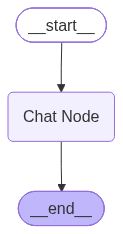

In [13]:
chatbot

In [16]:
thread_id = "1"

while True:
    user_message = input('Type here: ')
    print('User:', user_message)
    if user_message.strip().lower() in ['exit','quit','bye']:
        print('AI: Thanks for the visting!')
        break
    config = {'configurable' : {'thread_id':thread_id}}
    response = chatbot.invoke({'messages':[HumanMessage(content = user_message)]}, config = config)
    print('AI:', response['messages'][-1].content)

User: hi
AI: Hi there! 👋 How can I assist you today?
User: bye
AI: Thanks for the visting!
